<a href="https://colab.research.google.com/github/bereketsimma/Beautysalon-booking/blob/main/wordembading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install gensim
!pip install nltk
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn


import os
import random

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models import Word2Vec
from gensim.models.keyedvectors import KeyedVectors  # handle word vectors separately

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import nltk


[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [32]:
import gensim.downloader as api

dataset = api.load("text8")

corpus_text8 = list(dataset)
print("Number of sentences:", len(corpus_text8))

total_words = sum(len(s) for s in corpus_text8)
print("Total words:", total_words)

vocab_size = len(set(w for s in corpus_text8 for w in s))
print("Vocabulary size:", vocab_size)


for i in range(3):
    print(f"Sentence {i+1}:", corpus_text8[i][:20])
def preprocess(sent):
    return [w.lower() for w in sent if w.isalpha()]

corpus_text8_clean = [preprocess(s) for s in corpus_text8]
print("Clean sentences:", len(corpus_text8_clean))
print("Clean vocab size:", len(set([w for s in corpus_text8_clean for w in s])))
print("Clean example sentence:", corpus_text8_clean[0][:20])

Number of sentences: 1701
Total words: 17005207
Vocabulary size: 253854
Sentence 1: ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']
Sentence 2: ['reciprocity', 'qualitative', 'impairments', 'in', 'communication', 'as', 'manifested', 'by', 'at', 'least', 'one', 'of', 'the', 'following', 'delay', 'in', 'or', 'total', 'lack', 'of']
Sentence 3: ['with', 'the', 'aegis', 'of', 'zeus', 'when', 'he', 'goes', 'to', 'the', 'battlefield', 'the', 'entire', 'trojan', 'army', 'flees', 'behind', 'the', 'walls', 'of']
Clean sentences: 1701
Clean vocab size: 253854
Clean example sentence: ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']


In [31]:


# Cell 4: Train Word2Vec (CBOW)

embedding_dim = 100
window_size = 5       # context window
min_count = 1         # ignore rare words
sg = 0
workers = 4
epochs = 5

model_cbow = Word2Vec(
    sentences=corpus_text8_clean,
    vector_size=embedding_dim,
    window=window_size,
    min_count=min_count,
    sg=sg,
    workers=workers,
    epochs=epochs,
    seed=42,
    compute_loss=True
)
model_cbow.save("word2vec_cbow_demo.model")


print("Vocabulary size:", len(model_cbow.wv.index_to_key))
print("First 10 words:", model_cbow.wv.index_to_key[:10])
print("Vector for 'king':\n", model_cbow.wv["king"])


Vocabulary size: 253854
First 10 words: ['the', 'of', 'and', 'one', 'in', 'a', 'to', 'zero', 'nine', 'two']
Vector for 'king':
 [ 0.7840103  -0.30270162 -1.3587259  -0.09017508  0.9294001   0.16762622
  0.86448497  1.5979974  -4.509692   -2.018312   -2.0925567   2.9271693
  1.8042877   0.08360874 -1.7412472  -0.47598448  1.5201533   0.97723377
  1.0279173  -0.056481    1.6713507   0.64212406  2.4440267  -1.3908776
  1.5364593   0.58748394 -3.7415504   0.25579897 -1.0173658   2.1821773
  1.132001   -0.47349986 -0.26424637 -0.4642875   1.7788882   1.0932345
 -1.7396147   1.0762372  -2.9333093  -2.0450056  -0.5168873   4.692348
  1.7181925   0.5423875   1.5865479   1.2561421  -2.8294418  -0.89601713
  1.9155905   0.69790107  2.154793    0.36109194  1.4296876  -0.5813816
  2.1672347   2.1465914   1.8271167   1.6247225  -0.53629434  1.1591686
 -1.2430855  -0.4118272   0.5137955  -0.53365713 -1.6070734   1.6872908
 -0.8478383   1.2128073  -0.06707599  3.0591784   1.2643483   3.3920913
  0.64

In [33]:

# Cell 4: Train Word2Vec
embedding_dim = 100
window_size = 5
min_count = 5
sg = 1
workers = 4
epochs = 5

model_skip = Word2Vec(
    sentences=corpus_text8_clean,
    vector_size=embedding_dim,
    window=window_size,
    min_count=min_count,
    sg=sg,
    workers=workers,
    epochs=epochs,
    seed=42,
    compute_loss=True

)
model_skip.save("word2vec_cbow_demo.model")


print("Vocabulary size:", len(model_skip.wv.index_to_key))
print("First 10 words:", model_skip.wv.index_to_key[:10])
print("Vector for 'king':\n", model_skip.wv["king"])



Vocabulary size: 71290
First 10 words: ['the', 'of', 'and', 'one', 'in', 'a', 'to', 'zero', 'nine', 'two']
Vector for 'king':
 [ 0.34052393  0.339012   -0.38309744 -0.23971845  0.19164771  0.03757699
  0.68749577  0.31833893  0.08836792  0.06838087 -0.48489195  0.12645745
 -0.13414024 -0.06061281 -0.87728906 -0.772962    0.14910008  0.07152077
 -0.04254723  0.04238963  0.26746166  0.31435978  0.31961766 -0.02595611
  0.46053615 -0.2883099   0.34726962  0.29706988 -0.684631    0.04527416
  0.22991987 -0.25723377  0.40505463 -0.09055685  0.34564346 -0.45517236
  0.0548705  -0.45746532 -0.8764904   0.26172718  0.12590298  0.03512132
 -0.18926924  0.27903515  0.5158337  -0.17701426 -0.03668493  0.16719154
  0.6740318   0.20951334  0.07176603 -0.5835475   0.31519458 -0.03136683
 -0.09738559  0.24938513 -0.3637569   0.4239065   0.10383023  0.18343066
  0.17408977  0.22495387 -0.00218157  0.39207497  0.14500342  0.00393212
 -0.00559335 -0.09412958 -0.00157684  0.19724573 -0.00944543 -0.073072

In [22]:
try:
    print("Skip-gram loss:", model_skip.get_latest_training_loss())
except NameError:
    print("Error: 'model_skip' is not defined. Please ensure the Word2Vec Skip-gram model cell (TREZhtbuFGMP) has been executed.")

print("CBOW loss:", model_cbow.get_latest_training_loss())

Skip-gram loss: 68187864.0
CBOW loss: 23354694.0


In [23]:
# Cell 5: Similarity examples
def show_similar(model , word, topn=10):
    if word in model.wv:
        print(f"Top {topn} similar to '{word}':")
        for w, score in model.wv.most_similar(word, topn=topn):
            print(f"  {w:15s}  {score:.4f}")
    else:
        print(f"'{word}' not in vocabulary (min_count may have filtered it).")
words = ["king", "paris", "woman", "small", "man"]
for w in words:
    if w in model_cbow.wv:
        print("\nWord:", w,"with cbow")
        print(model_cbow.wv.most_similar(w, topn=5))
        print("\nWord:", w ,"with skip_gram")
        print(model_skip.wv.most_similar(w, topn=5))

print(model_cbow.wv.most_similar(positive=["king","woman"], negative=["man"], topn=1))

print(model_cbow.wv.most_similar(positive=["paris","germany"], negative=["france"], topn=1))

print(model_cbow.wv.most_similar(positive=["small","bigger"], negative=["big"], topn=1))




print(model_skip.wv.most_similar(positive=["king","woman"], negative=["man"], topn=1))

print(model_skip.wv.most_similar(positive=["paris","germany"], negative=["france"], topn=1))

print(model_skip.wv.most_similar(positive=["small","bigger"], negative=["big"], topn=1))




Word: king with cbow
[('prince', 0.7576401829719543), ('emperor', 0.7185749411582947), ('queen', 0.7176956534385681), ('kings', 0.7027970552444458), ('throne', 0.6974907517433167)]

Word: king with skip_gram
[('canute', 0.743200421333313), ('vii', 0.7359427213668823), ('kings', 0.7309436202049255), ('throne', 0.7278324961662292), ('pretender', 0.7274895310401917)]

Word: paris with cbow
[('vienna', 0.7644087672233582), ('venice', 0.753117561340332), ('munich', 0.7226195335388184), ('leipzig', 0.7025874257087708), ('milan', 0.7021595239639282)]

Word: paris with skip_gram
[('brussels', 0.7514417767524719), ('conservatoire', 0.7374875545501709), ('universelle', 0.7368893623352051), ('montparnasse', 0.7270585298538208), ('france', 0.7268803715705872)]

Word: woman with cbow
[('child', 0.8136312961578369), ('girl', 0.7599478960037231), ('man', 0.7437050938606262), ('mother', 0.6859674453735352), ('lady', 0.6845666170120239)]

Word: woman with skip_gram
[('man', 0.7285984754562378), ('chil

In [52]:
# Skip-gram vocabulary
vocab_skip = model_skip.wv.index_to_key
words_to_plot_skip = vocab_skip[:50]

# CBOW vocabulary
vocab_cbow = model_cbow.wv.index_to_key
words_to_plot_cbow = vocab_cbow[:50]


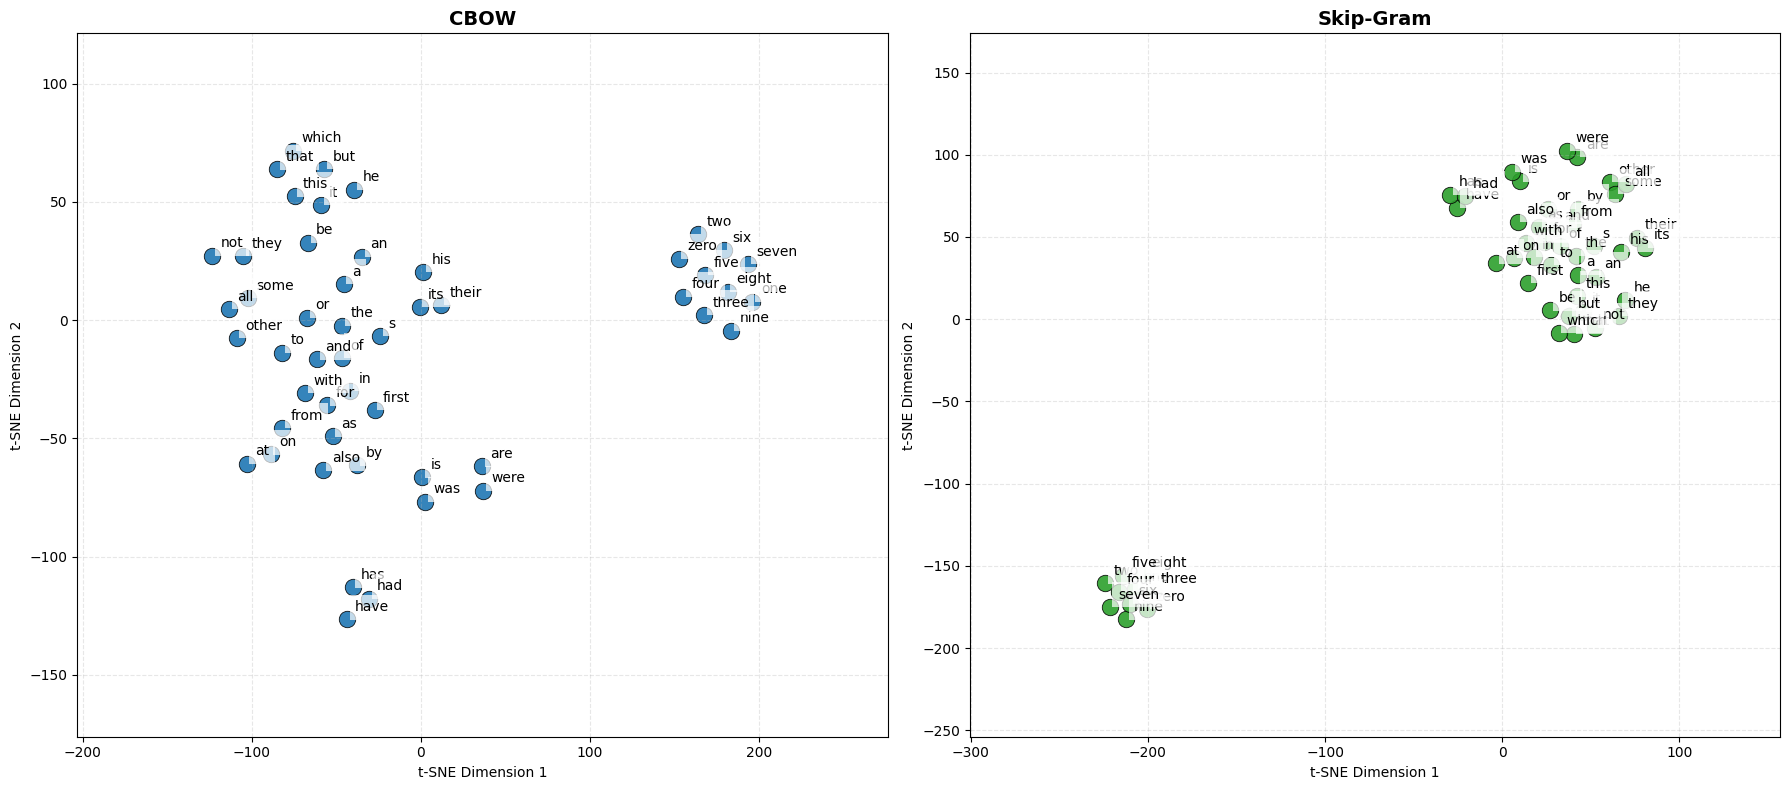

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, model, words_to_plot, title, color in [
    (axes[0], model_cbow, words_to_plot_cbow, "CBOW", "tab:blue"),
    (axes[1], model_skip, words_to_plot_skip, "Skip-Gram", "tab:green")
]:

    # Get word vectors
    vectors = np.array([model.wv[w] for w in words_to_plot])

    # PCA reduction (stabilizes t-SNE)
    pca = PCA(n_components=min(10, vectors.shape[1]), random_state=42)
    vecs_pca = pca.fit_transform(vectors)

    # t-SNE (better separation + stability)
    tsne = TSNE(
        n_components=2,
        perplexity=10,        # slightly lower → better separation for small word sets
        learning_rate=200,    # smoother spread
        max_iter=1500,        # better convergence
        init="pca",
        random_state=42
    )

    vecs_2d = tsne.fit_transform(vecs_pca)

    # Scatter plot
    ax.scatter(
        vecs_2d[:, 0],
        vecs_2d[:, 1],
        s=140,
        c=color,
        alpha=0.9,
        edgecolors='black',
        linewidths=0.6
    )

    # Labels with better offset (prevents tight overlap)
    for i, word in enumerate(words_to_plot):
        ax.annotate(
            word,
            (vecs_2d[i, 0], vecs_2d[i, 1]),
            textcoords="offset points",
            xytext=(6, 6),   # fixed spacing
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")

    ax.grid(True, linestyle='--', alpha=0.3)

    ax.margins(0.25)

plt.tight_layout()
plt.show()

In [26]:
!git clone https://github.com/bereketsimma/wordembading.git


Cloning into 'wordembading'...


In [27]:
%cd wordembading


/content/wordembading


In [29]:
from google.colab import drive
drive.mount('/content/drive')
!find /content/drive/MyDrive -name "*.ipynb"

MessageError: Error: credential propagation was unsuccessful

In [ ]:
%cd /content/wordembading/wordembading


In [ ]:
!git remote -v

In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/wordembading.ipynb" .
!ls

!git config --global user.name "bereketsimma"
!git config --global user.email "bekisimma@gmail.com"
!git add wordembading.ipynb
!git commit -m "Add Word2Vec Colab notebook"
!git push -u origin main

In [ ]:
!ls
!git status
!git branch --unset-upstream